In [1]:
!git clone https://github.com/dibakar1612/KMeans-Customer-Segmentation.git

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

print("Environment setup complete and repository cloned!")

Cloning into 'KMeans-Customer-Segmentation'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 26 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 9.16 KiB | 4.58 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Environment setup complete and repository cloned!


In [4]:

url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"
train_df = pd.read_csv(url)


X_train = train_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

print("Standard Training Data Sample:")
print(X_train.head())

Standard Training Data Sample:
   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                      81
2   20                  16                       6
3   23                  16                      77
4   31                  17                      40


In [5]:
# Initialize the feature scaler
scaler = StandardScaler()

# Fit the scaler to our training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

print("Data scaled successfully! Here is a glimpse of the scaled array:")
print(X_train_scaled[:5])

Data scaled successfully! Here is a glimpse of the scaled array:
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


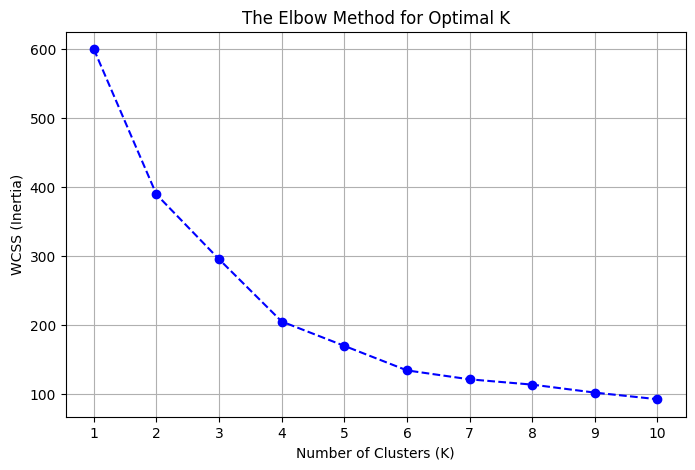

In [6]:
# Create an empty list to store the WCSS/Inertia values
wcss = []

# Loop through cluster sizes 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)  # Track within-cluster sum of squares

# Generate the Elbow Curve Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [7]:

optimal_k = 5
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)


train_clusters = kmeans_model.fit_predict(X_train_scaled)


joblib.dump(kmeans_model, 'model.pkl')

print("Model successfully trained on standard dataset and saved locally as 'model.pkl'!")

Model successfully trained on standard dataset and saved locally as 'model.pkl'!


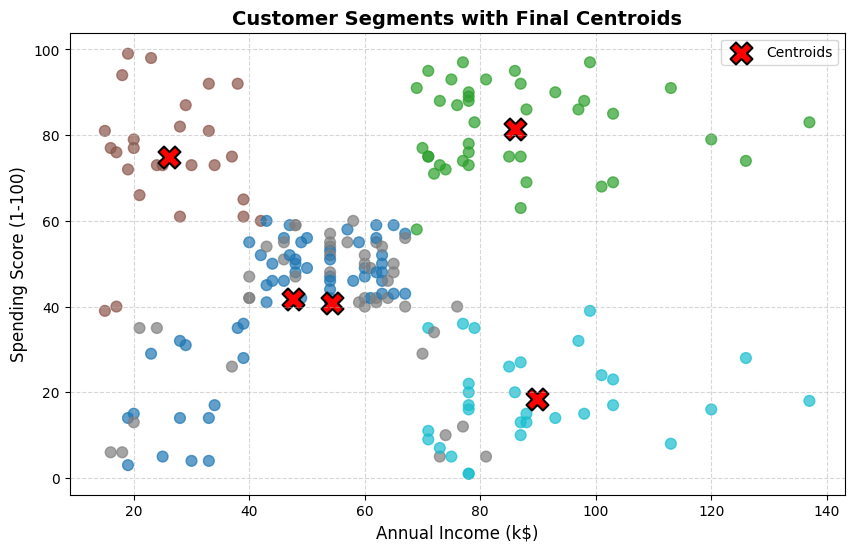

In [13]:
plt.figure(figsize=(10, 6))


scatter = plt.scatter(X_train.iloc[:, 1], X_train.iloc[:, 2],
                      c=train_clusters, cmap='tab10', s=60, alpha=0.7)


centroids_scaled = kmeans_model.cluster_centers_


centroids_original = scaler.inverse_transform(centroids_scaled)


plt.scatter(centroids_original[:, 1], centroids_original[:, 2],
            s=250, c='red', marker='X', edgecolor='black', linewidth=1.5, label='Centroids')


plt.title('Customer Segments with Final Centroids', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [20]:
repo_path = '/content/KMeans-Customer-Segmentation/Dataset/custom_customers.csv'
custom_df = pd.read_csv('/content/KMeans-Customer-Segmentation/Dataset/custom_customers.csv')

X_custom = custom_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

X_custom_scaled = scaler.transform(X_custom)

custom_predictions = kmeans_model.predict(X_custom_scaled)

custom_df['Assigned Cluster ID'] = custom_predictions
print("--- Custom Data Real-World Test Predictions ---")
display(custom_df)

--- Custom Data Real-World Test Predictions ---


,Age,Annual Income (k$),Spending Score (1-100),Assigned Cluster ID
0,25,20,81,2
1,40,60,45,3
2,60,90,15,4
3,19,15,20,3
4,32,75,92,1
5,55,50,41,0
6,48,120,18,4
7,22,85,75,1
8,35,30,6,3
9,28,88,85,1
